In [3]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/manishkr1754/cardekho-used-car-data/cardekho_dataset.csv


In [4]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

In [5]:
df = pd.read_csv("/kaggle/input/datasets/manishkr1754/cardekho-used-car-data/cardekho_dataset.csv")
df.head()

,Unnamed: 0,car_name,brand,model,vehicle_age,km_driven,seller_type,fuel_type,transmission_type,mileage,engine,max_power,seats,selling_price
0,0,Maruti Alto,Maruti,Alto,9,120000,Individual,Petrol,Manual,19.70,796,46.30,5,120000
1,1,Hyundai Grand,Hyundai,Grand,5,20000,Individual,Petrol,Manual,18.90,1197,82.00,5,550000
2,2,Hyundai i20,Hyundai,i20,11,60000,Individual,Petrol,Manual,17.00,1197,80.00,5,215000
3,3,Maruti Alto,Maruti,Alto,9,37000,Individual,Petrol,Manual,20.92,998,67.10,5,226000
4,4,Ford Ecosport,Ford,Ecosport,6,30000,Dealer,Diesel,Manual,22.77,1498,98.59,5,570000


In [6]:
df.isnull().sum()[df.isnull().sum() > 0]

Series([], dtype: int64)

In [7]:
df.duplicated().sum()

np.int64(0)

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15411 entries, 0 to 15410
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Unnamed: 0         15411 non-null  int64  
 1   car_name           15411 non-null  object 
 2   brand              15411 non-null  object 
 3   model              15411 non-null  object 
 4   vehicle_age        15411 non-null  int64  
 5   km_driven          15411 non-null  int64  
 6   seller_type        15411 non-null  object 
 7   fuel_type          15411 non-null  object 
 8   transmission_type  15411 non-null  object 
 9   mileage            15411 non-null  float64
 10  engine             15411 non-null  int64  
 11  max_power          15411 non-null  float64
 12  seats              15411 non-null  int64  
 13  selling_price      15411 non-null  int64  
dtypes: float64(2), int64(6), object(6)
memory usage: 1.6+ MB


In [9]:
num_cols = df.select_dtypes(include="number").columns
cat_cols = df.select_dtypes(include="object").columns

print("num_cols:", num_cols)
print("cat_cols:", cat_cols)

num_cols: Index(['Unnamed: 0', 'vehicle_age', 'km_driven', 'mileage', 'engine',
       'max_power', 'seats', 'selling_price'],
      dtype='object')
cat_cols: Index(['car_name', 'brand', 'model', 'seller_type', 'fuel_type',
       'transmission_type'],
      dtype='object')


In [10]:
df = df.drop('Unnamed: 0', axis=1)

In [11]:
df

,car_name,brand,model,vehicle_age,km_driven,seller_type,fuel_type,transmission_type,mileage,engine,max_power,seats,selling_price
0,Maruti Alto,Maruti,Alto,9,120000,Individual,Petrol,Manual,19.70,796,46.30,5,120000
1,Hyundai Grand,Hyundai,Grand,5,20000,Individual,Petrol,Manual,18.90,1197,82.00,5,550000
2,Hyundai i20,Hyundai,i20,11,60000,Individual,Petrol,Manual,17.00,1197,80.00,5,215000
3,Maruti Alto,Maruti,Alto,9,37000,Individual,Petrol,Manual,20.92,998,67.10,5,226000
4,Ford Ecosport,Ford,Ecosport,6,30000,Dealer,Diesel,Manual,22.77,1498,98.59,5,570000
...,...,...,...,...,...,...,...,...,...,...,...,...,...
15406,Hyundai i10,Hyundai,i10,9,10723,Dealer,Petrol,Manual,19.81,1086,68.05,5,250000
15407,Maruti Ertiga,Maruti,Ertiga,2,18000,Dealer,Petrol,Manual,17.50,1373,91.10,7,925000
15408,Skoda Rapid,Skoda,Rapid,6,67000,Dealer,Diesel,Manual,21.14,1498,103.52,5,425000
15409,Mahindra XUV500,Mahindra,XUV500,5,3800000,Dealer,Diesel,Manual,16.00,2179,140.00,7,1225000


In [12]:
corr_num = df.select_dtypes(include='number').corr()['selling_price'].sort_values(ascending=False)

print("Corr of number col:", corr_num)

Corr of number col: selling_price    1.000000
max_power        0.750236
engine           0.585844
seats            0.115033
km_driven       -0.080030
vehicle_age     -0.241851
mileage         -0.305549
Name: selling_price, dtype: float64


In [13]:
X = df.drop("selling_price", axis=1)
y = df["selling_price"]

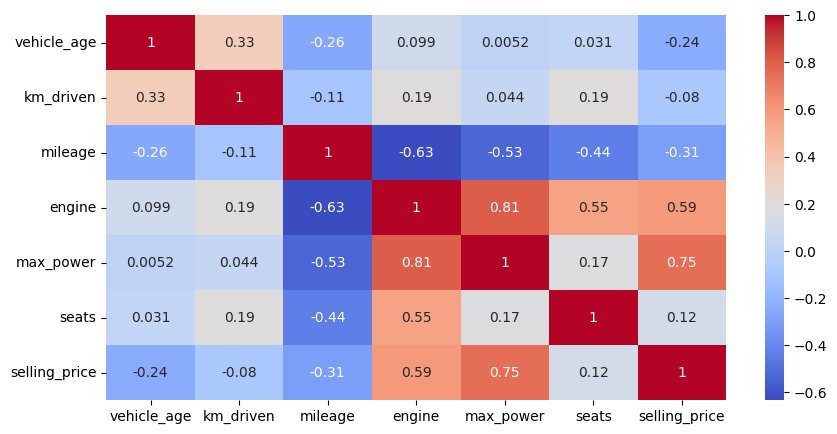

In [14]:
plt.figure(figsize=(10, 5))
sns.heatmap(df.select_dtypes(include='number').corr(), annot=True, cmap='coolwarm')
plt.show()

In [15]:
for col in cat_cols:
    print("\n", df[col])
    print(df[col].value_counts())


 0            Maruti Alto
1          Hyundai Grand
2            Hyundai i20
3            Maruti Alto
4          Ford Ecosport
              ...       
15406        Hyundai i10
15407      Maruti Ertiga
15408        Skoda Rapid
15409    Mahindra XUV500
15410         Honda City
Name: car_name, Length: 15411, dtype: object
car_name
Hyundai i20              906
Maruti Swift Dzire       890
Maruti Swift             781
Maruti Alto              778
Honda City               757
                        ... 
Mercedes-AMG C             1
Rolls-Royce Ghost          1
Maserati Quattroporte      1
Isuzu MUX                  1
Force Gurkha               1
Name: count, Length: 121, dtype: int64

 0          Maruti
1         Hyundai
2         Hyundai
3          Maruti
4            Ford
           ...   
15406     Hyundai
15407      Maruti
15408       Skoda
15409    Mahindra
15410       Honda
Name: brand, Length: 15411, dtype: object
brand
Maruti           4992
Hyundai          2982
Honda            14

In [16]:
for col in cat_cols:
    print(col, ":", df[col].nunique())

car_name : 121
brand : 32
model : 120
seller_type : 3
fuel_type : 5
transmission_type : 2


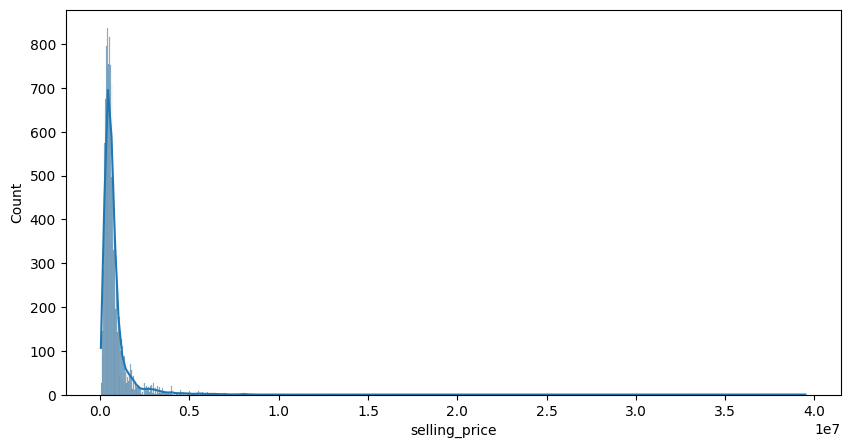

In [17]:
# Target Value ka Skew  checking

plt.figure(figsize=(10, 5))
sns.histplot(df['selling_price'], kde=True)
plt.show()

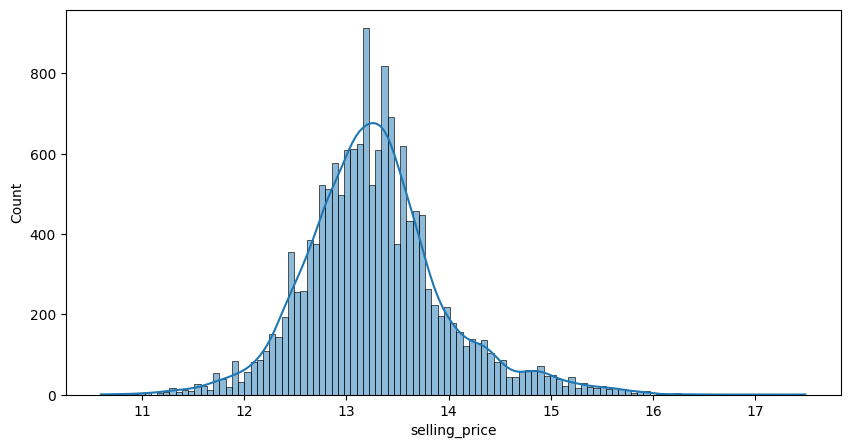

In [18]:
y = np.log1p(y)


plt.figure(figsize=(10, 5))
sns.histplot(y, kde=True)
plt.show()

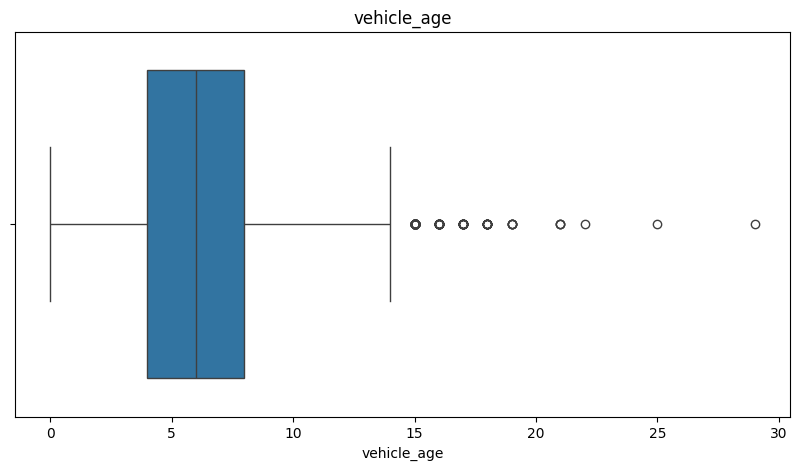

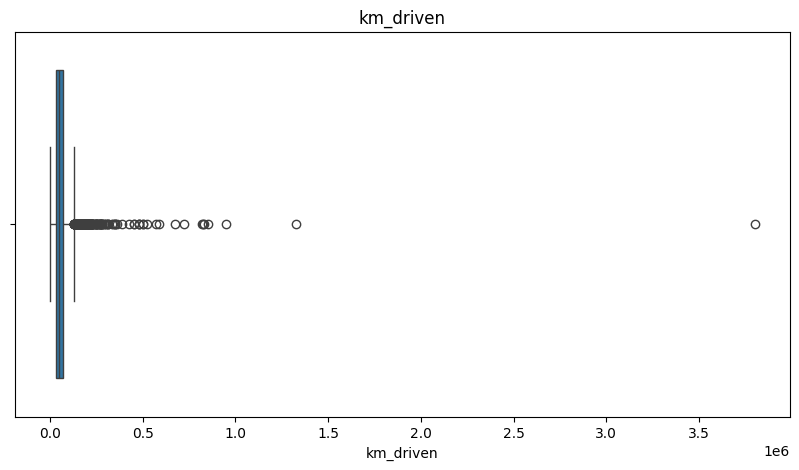

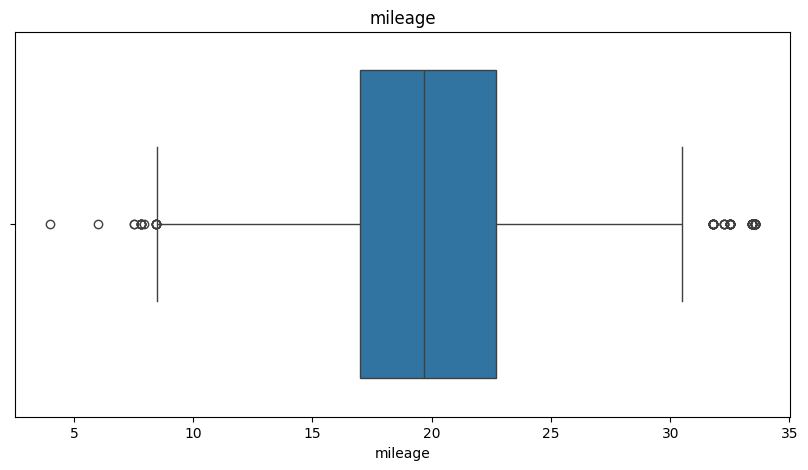

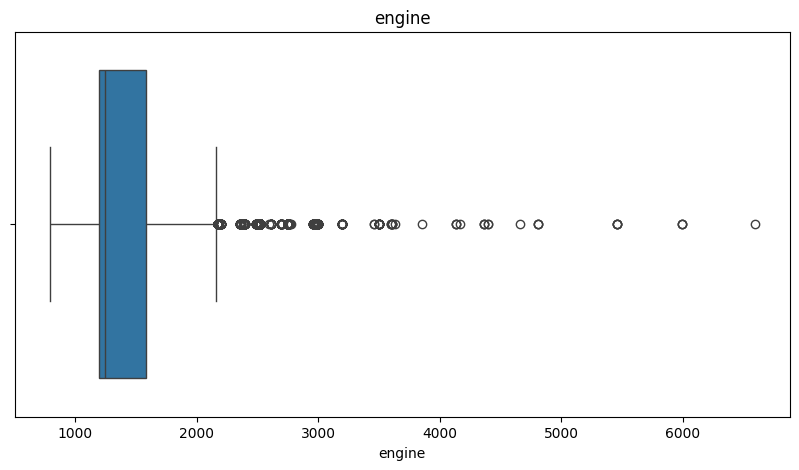

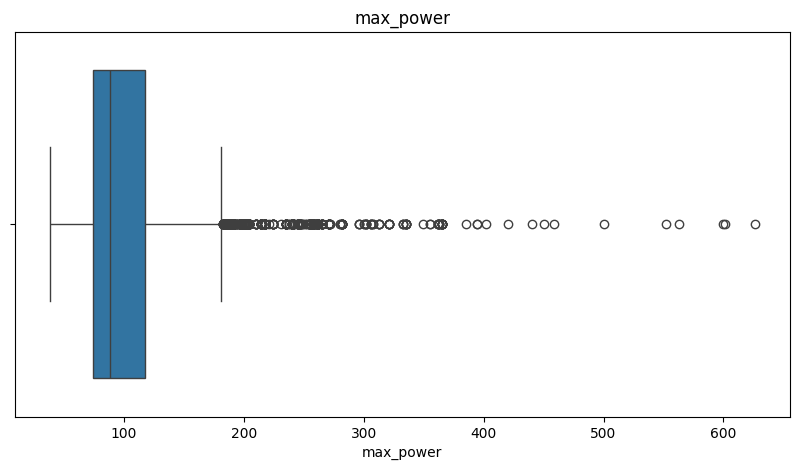

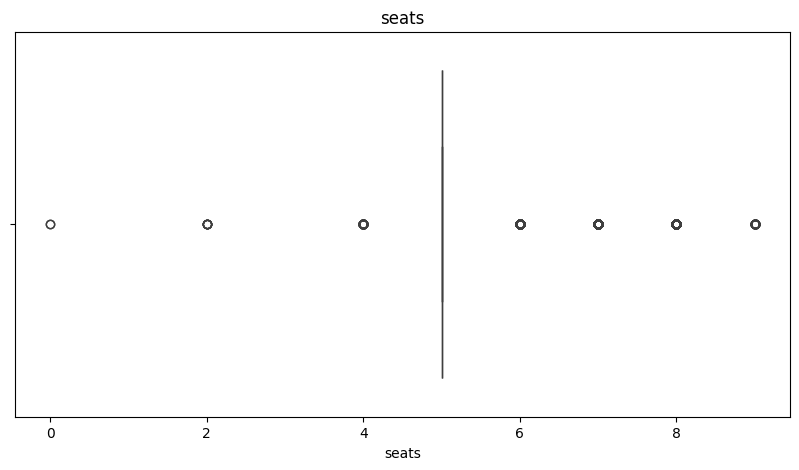

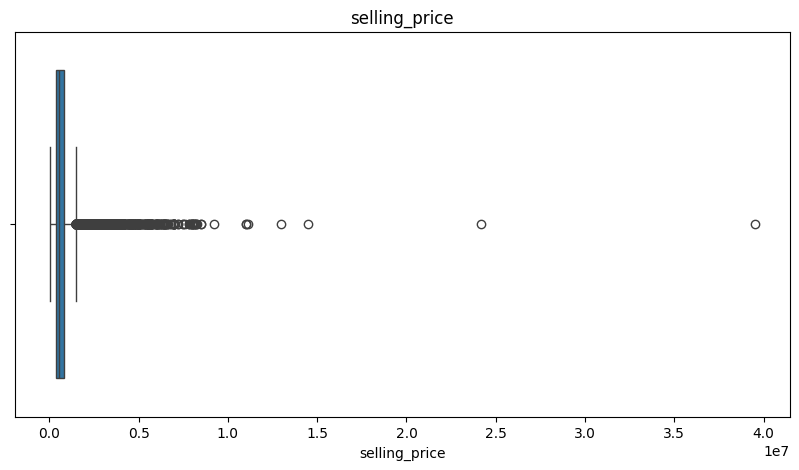

In [19]:
num_cols = df.select_dtypes(include='number').columns

for col in num_cols:
    plt.figure(figsize=(10, 5))
    sns.boxplot(x=df[col])
    plt.title(col)
    plt.show()

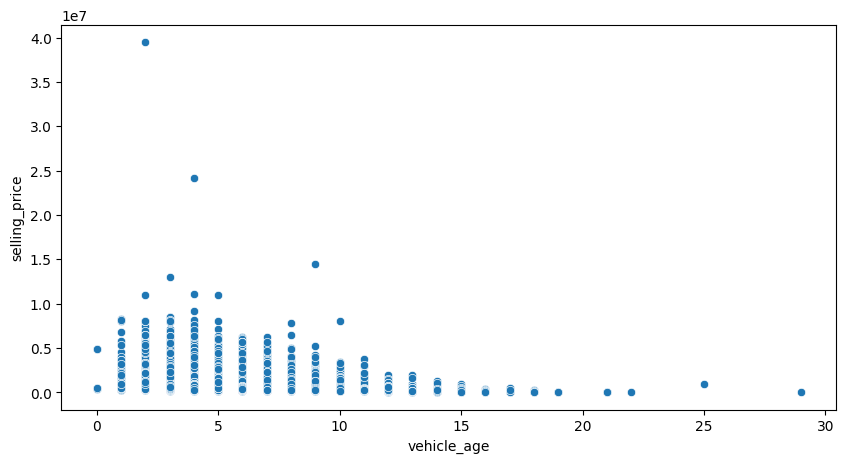

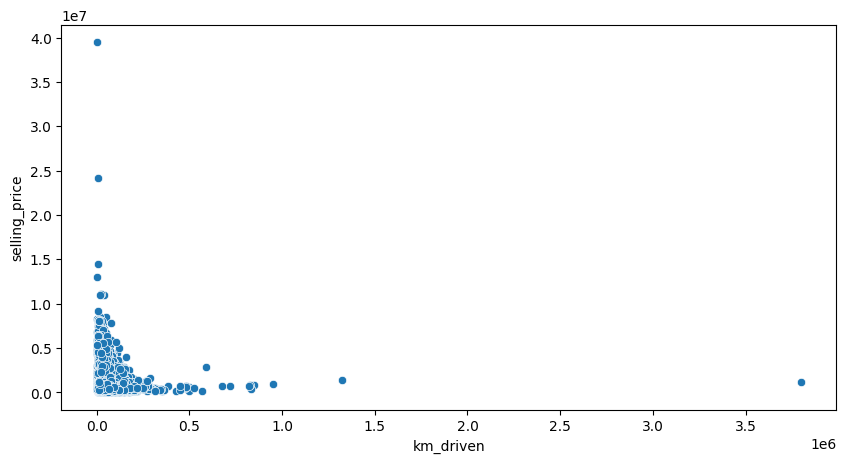

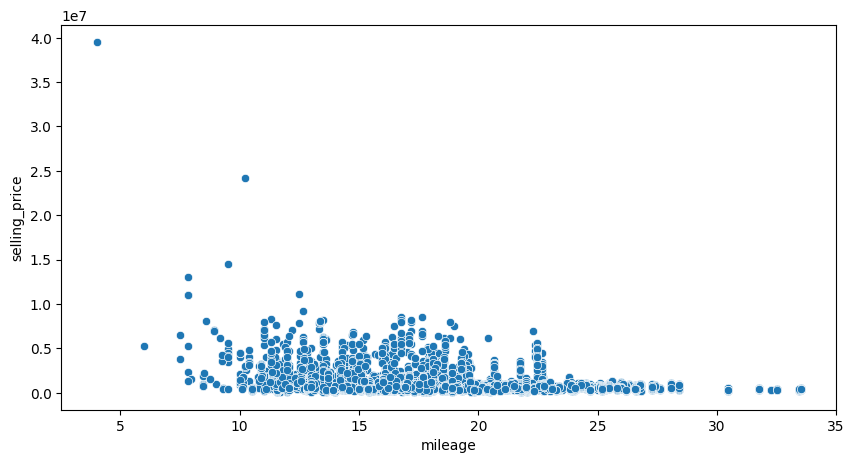

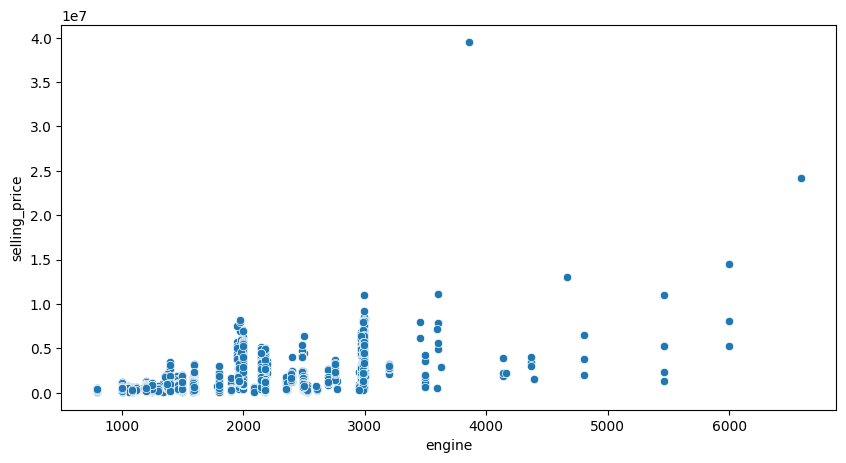

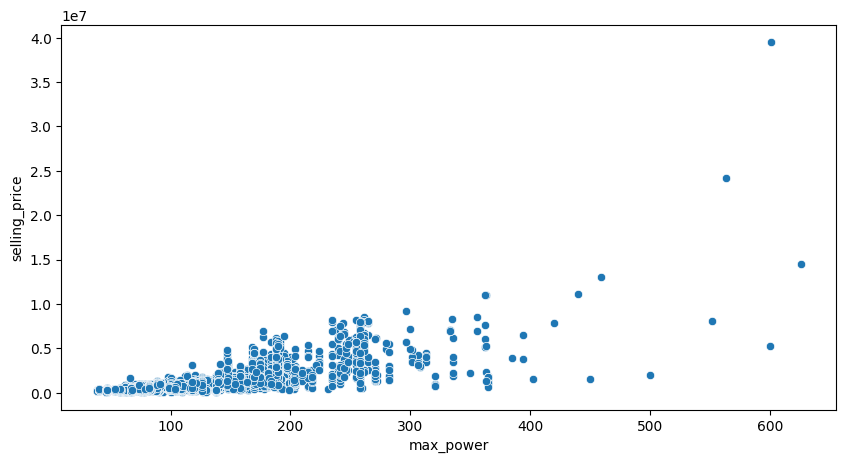

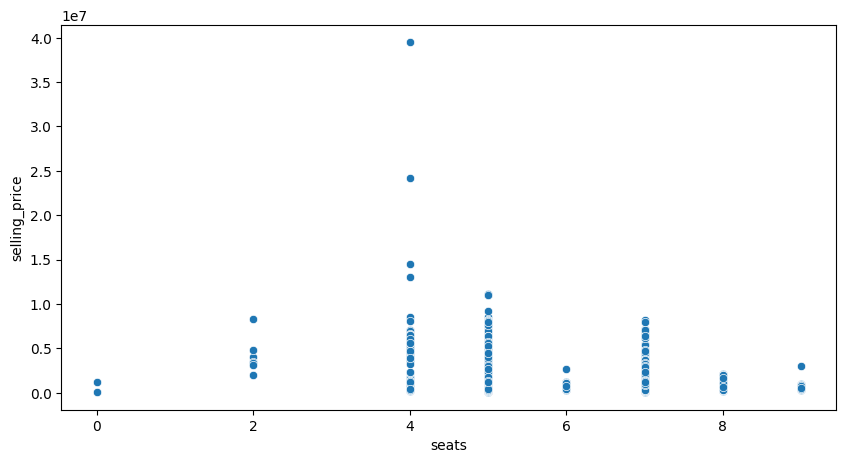

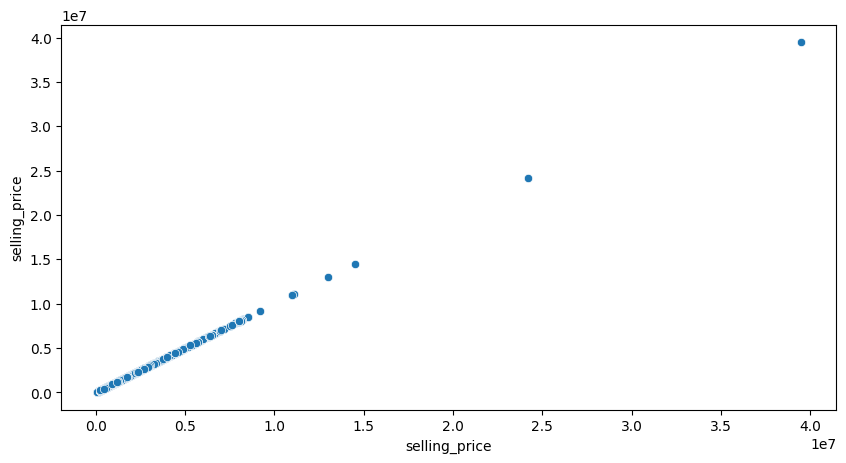

In [20]:
for col in num_cols:
    plt.figure(figsize=(10, 5))
    sns.scatterplot(data=df, x=df[col], y='selling_price')
    plt.show()

In [21]:
cat_cols = df.select_dtypes(include='object').columns

print(cat_cols)

Index(['car_name', 'brand', 'model', 'seller_type', 'fuel_type',
       'transmission_type'],
      dtype='object')


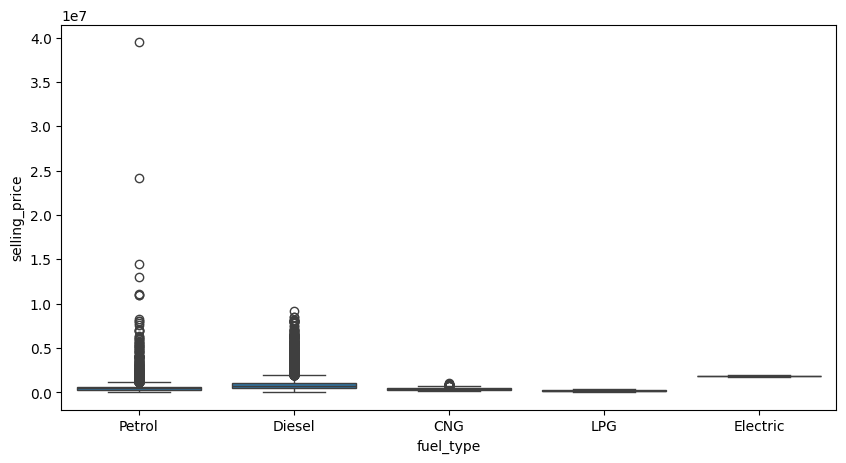

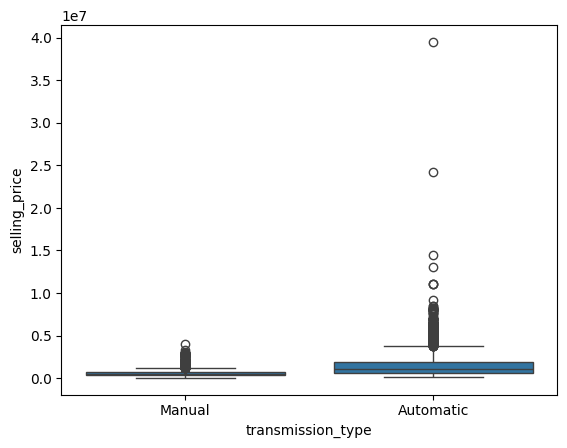

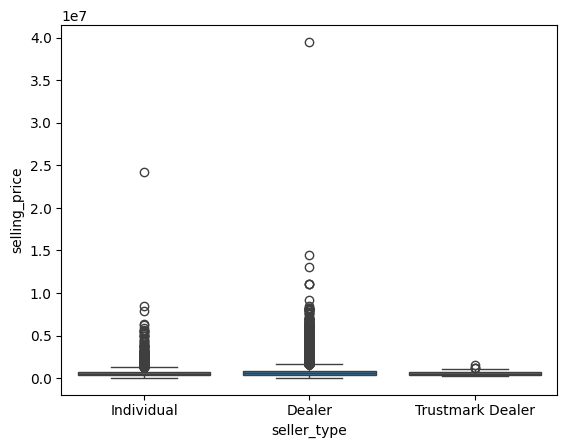

In [22]:
# Categorial vs Selling Price

plt.figure(figsize=(10, 5))
sns.boxplot(data=df, x='fuel_type', y='selling_price')
plt.show()

sns.boxplot(data=df, x='transmission_type', y='selling_price')
plt.show()

sns.boxplot(data=df, x='seller_type', y='selling_price')
plt.show()

In [23]:
num_cols = ['vehicle_age', 'km_driven', 'mileage', 'engine','max_power', 'seats']

for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q2 = df[col].quantile(0.75)

    IQR = Q2 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q2 - 1.5 * IQR

    outliers = df[(df[col] < lower) | (df[col] > upper)]

    print(f"{col}: {len(outliers)} outliers")

vehicle_age: 14040 outliers
km_driven: 14487 outliers
mileage: 13790 outliers
engine: 13292 outliers
max_power: 14899 outliers
seats: 2501 outliers


In [24]:
for col in cat_cols:
    print(f"\n{col}")
    print(df.groupby(col)['selling_price'].agg(['count', 'mean', 'median']).sort_values('count', ascending=False).head(3))


car_name
                    count           mean    median
car_name                                          
Hyundai i20           906  543603.752759  550000.0
Maruti Swift Dzire    890  525888.764045  523000.0
Maruti Swift          781  471736.235595  465000.0

brand
         count           mean    median
brand                                  
Maruti    4992  487089.317909  465000.0
Hyundai   2982  576153.923541  525000.0
Honda     1485  617756.902357  590000.0

model
             count           mean    median
model                                      
i20            906  543603.752759  550000.0
Swift Dzire    890  525888.764045  523000.0
Swift          781  471736.235595  465000.0

seller_type
                  count           mean    median
seller_type                                     
Dealer             9539  872505.503722  591000.0
Individual         5699  617880.483418  507000.0
Trustmark Dealer    173  571959.537572  540000.0

fuel_type
           count          mean  

In [25]:
X = df.drop("selling_price", axis=1)
y = df['selling_price']
# y = np.log1p(y)


X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state = 42
)


print(X_train.shape)
print(X_test.shape)

(12328, 12)
(3083, 12)


In [26]:
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer

cat_cols = X.select_dtypes(include='object').columns
num_cols = X.select_dtypes(include='number').columns

preprocessor = ColumnTransformer(
    transformers = [
        ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols),
        ('num', StandardScaler(), num_cols)
    ]
)

X_train_encoded = preprocessor.fit_transform(X_train)
X_test_encoded = preprocessor.transform(X_test)

print("Before encoding:", X_train.shape)
print("After encoding:", X_train_encoded.shape)

Before encoding: (12328, 12)
After encoding: (12328, 283)


In [27]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()

model.fit(X_train_encoded, y_train)

y_pred = model.predict(X_test_encoded)

# y_pred_price = np.expm1(y_pred)
print(y_pred[:10])

[  71270.08130027  615206.91844089  625495.831555   1222551.33304464
  -55825.24330306  432614.53090794  319796.99045164  252399.52503029
  360149.90538631 1837210.86396227]


In [28]:
from sklearn.metrics import mean_absolute_error,mean_squared_error, r2_score
import numpy as np

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("MAE :", mae)
print("MSE :", mse)
print("RMSE :", rmse)
print("R2 :", r2)


MAE : 177594.37528661525
MSE : 150826589506.3553
RMSE : 388363.991001168
R2 : 0.7996410229190851


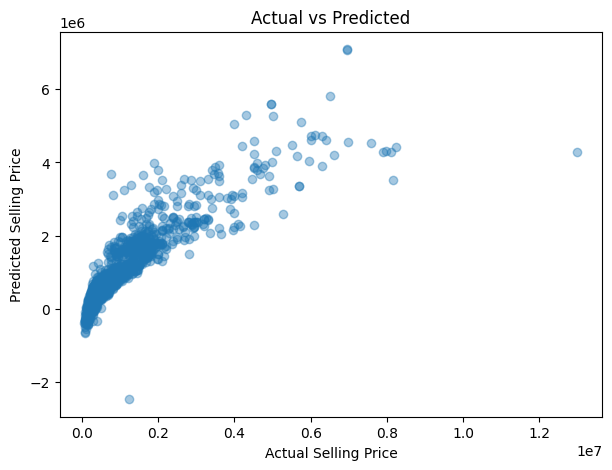

In [29]:
plt.figure(figsize=(7, 5))
plt.scatter(y_test, y_pred, alpha=0.4)

plt.xlabel("Actual Selling Price")
plt.ylabel("Predicted Selling Price")
plt.title("Actual vs Predicted")
plt.show()

In [30]:
results = pd.DataFrame(
    {
        'actual': y_test,
        'predicted': y_pred
    }
)

results['error'] = results['actual'] - results['predicted']
results['abs_error'] = results['error'].abs()

print(results.sort_values('abs_error', ascending=False).head(10))

         actual     predicted         error     abs_error
9722   13000000  4.295699e+06  8.704301e+06  8.704301e+06
3410    8150000  3.520643e+06  4.629357e+06  4.629357e+06
311     8250000  4.422913e+06  3.827087e+06  3.827087e+06
12827   8100000  4.296182e+06  3.803818e+06  3.803818e+06
15409   1225000 -2.466242e+06  3.691242e+06  3.691242e+06
9357    7985000  4.299338e+06  3.685662e+06  3.685662e+06
351     7900000  4.272236e+06  3.627764e+06  3.627764e+06
12421   7595000  4.530891e+06  3.064109e+06  3.064109e+06
13481    750000  3.688048e+06 -2.938048e+06  2.938048e+06
1740    5275000  2.596666e+06  2.678334e+06  2.678334e+06


In [31]:
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(
    n_estimators = 100,
    random_state = 42,
    n_jobs = -1
)

rf_model.fit(X_train_encoded, y_train)
rf_pred = rf_model.predict(X_test_encoded)

rf_mae = mean_absolute_error(y_test, rf_pred)
rf_mse = mean_squared_error(y_test, rf_pred)
rf_rmse = np.sqrt(rf_mse)
rf_r2 = r2_score(y_test, rf_pred)

print("RF MAE :", rf_mae)
print("RF RMSE:", rf_rmse)
print("RF R2  :", rf_r2)

RF MAE : 98452.50771281554
RF RMSE: 212100.5659345804
RF R2  : 0.9402394549941325


In [32]:
results_rf = pd.DataFrame({
    'actual': y_test,
    'predicted': rf_pred
})

results_rf['error'] = results_rf['actual'] - results_rf['predicted']
results_rf['abs_error'] = results_rf['error'].abs()

print(results_rf.sort_values('abs_error', ascending=False).head(10))

         actual   predicted      error  abs_error
9362    5100000   8520640.0 -3420640.0  3420640.0
9545    6000000   8695231.0 -2695231.0  2695231.0
14544   6400000   3874800.0  2525200.0  2525200.0
9722   13000000  10485000.0  2515000.0  2515000.0
14725   4900000   2537750.0  2362250.0  2362250.0
3710    2790000   4974840.0 -2184840.0  2184840.0
4304    4200000   2290120.0  1909880.0  1909880.0
10295   5950000   4105190.0  1844810.0  1844810.0
5035    6300000   4496090.0  1803910.0  1803910.0
10525    595000   2195320.0 -1600320.0  1600320.0


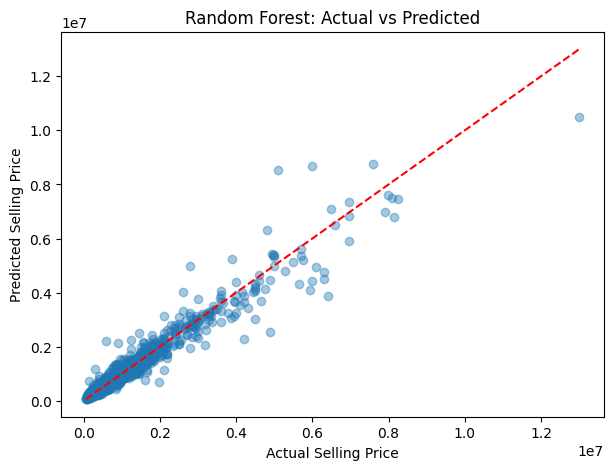

In [33]:
plt.figure(figsize=(7, 5))

plt.scatter(y_test, rf_pred, alpha=0.4)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r--'
)

plt.xlabel("Actual Selling Price")
plt.ylabel("Predicted Selling Price")
plt.title("Random Forest: Actual vs Predicted")

plt.show()

In [34]:
for n in [50, 100, 200, 300]:
    rf = RandomForestRegressor(
        n_estimators=n,
        random_state=42,
        n_jobs=-1
    )
    
    rf.fit(X_train_encoded, y_train)
    pred = rf.predict(X_test_encoded)
    
    print(
        "Trees:", n,
        "| MAE:", mean_absolute_error(y_test, pred),
        "| RMSE:", np.sqrt(mean_squared_error(y_test, pred)),
        "| R2:", r2_score(y_test, pred)
    )

Trees: 50 | MAE: 98314.88057658996 | RMSE: 210863.80339199468 | R2: 0.9409343528987375
Trees: 100 | MAE: 98452.50771281554 | RMSE: 212100.56593458037 | R2: 0.9402394549941325
Trees: 200 | MAE: 98197.32459274515 | RMSE: 213390.0412554972 | R2: 0.9395106121286572
Trees: 300 | MAE: 98217.15073177204 | RMSE: 214695.73066830653 | R2: 0.9387681033867593


In [35]:
for depth in [None, 5, 10, 15, 20, 25]:

    rf = RandomForestRegressor(
        n_estimators=50,
        max_depth=depth,
        random_state=42,
        n_jobs=-1
    )

    rf.fit(X_train_encoded, y_train)
    pred = rf.predict(X_test_encoded)

    print(
        "Depth:", depth,
        "| MAE:", mean_absolute_error(y_test, pred),
        "| RMSE:", np.sqrt(mean_squared_error(y_test, pred)),
        "| R2:", r2_score(y_test, pred)
    )

Depth: None | MAE: 98314.88057658996 | RMSE: 210863.80339199468 | R2: 0.9409343528987375
Depth: 5 | MAE: 158922.11321928608 | RMSE: 313561.2723168396 | R2: 0.8693902100981435
Depth: 10 | MAE: 106058.83224905828 | RMSE: 224689.66191063588 | R2: 0.9329348228028878
Depth: 15 | MAE: 98379.28673096694 | RMSE: 211415.5002105106 | R2: 0.9406248739085867
Depth: 20 | MAE: 98404.99386113443 | RMSE: 211324.7038031973 | R2: 0.9406758625114415
Depth: 25 | MAE: 98916.10167639816 | RMSE: 213598.3787441115 | R2: 0.9393924401746928


In [36]:
for leaf in [1, 2, 5, 10, 20]:

    rf = RandomForestRegressor(
        n_estimators=50,
        max_depth=None,
        min_samples_leaf=leaf,
        random_state=42,
        n_jobs=-1
    )

    rf.fit(X_train_encoded, y_train)
    pred = rf.predict(X_test_encoded)

    print(
        "Leaf:", leaf,
        "| MAE:", mean_absolute_error(y_test, pred),
        "| RMSE:", np.sqrt(mean_squared_error(y_test, pred)),
        "| R2:", r2_score(y_test, pred)
    )

Leaf: 1 | MAE: 98314.88057658996 | RMSE: 210863.80339199465 | R2: 0.9409343528987375
Leaf: 2 | MAE: 100048.96915824291 | RMSE: 217896.98786597388 | R2: 0.9369284726048067
Leaf: 5 | MAE: 107191.2626530034 | RMSE: 252099.78296883276 | R2: 0.9155740728901834
Leaf: 10 | MAE: 113587.57293533348 | RMSE: 260991.2244380927 | R2: 0.9095137261623039
Leaf: 20 | MAE: 120753.0225836737 | RMSE: 279447.2151641913 | R2: 0.8962637685312558


In [37]:
for split in [2, 5, 10, 20]:

    rf = RandomForestRegressor(
        n_estimators=50,
        max_depth=None,
        min_samples_leaf=1,
        min_samples_split=split,
        random_state=42,
        n_jobs=-1
    )

    rf.fit(X_train_encoded, y_train)
    pred = rf.predict(X_test_encoded)

    print(
        "Split:", split,
        "| MAE:", mean_absolute_error(y_test, pred),
        "| RMSE:", np.sqrt(mean_squared_error(y_test, pred)),
        "| R2:", r2_score(y_test, pred)
    )

Split: 2 | MAE: 98314.88057658996 | RMSE: 210863.80339199468 | R2: 0.9409343528987375
Split: 5 | MAE: 99149.8290923226 | RMSE: 216441.67564568686 | R2: 0.937768155993463
Split: 10 | MAE: 100272.54171131057 | RMSE: 222620.22817727306 | R2: 0.9341644994336422
Split: 20 | MAE: 103360.4588858571 | RMSE: 232347.12816440567 | R2: 0.9282857414343222


In [38]:
from sklearn.model_selection import cross_val_score

rf = RandomForestRegressor(
    n_estimators=50,
    max_depth=None,
    min_samples_leaf=1,
    min_samples_split=2,
    random_state=42,
    n_jobs=-1
)

cv_scores = cross_val_score(
    rf,
    X_train_encoded,
    y_train,
    cv=5,
    scoring='r2',
    n_jobs=-1
)

print("CV R2 scores:", cv_scores)
print("Mean CV R2:", cv_scores.mean())
print("Std CV R2:", cv_scores.std())

CV R2 scores: [0.9154272  0.71737468 0.94455571 0.93468001 0.85710447]
Mean CV R2: 0.8738284124073532
Std CV R2: 0.08389658871631755


In [39]:
from sklearn.model_selection import cross_validate

cv_results = cross_validate(
    rf,
    X_train_encoded,
    y_train,
    cv=5,
    scoring={
        'r2': 'r2',
        'mae': 'neg_mean_absolute_error',
        'rmse': 'neg_root_mean_squared_error'
    },
    n_jobs=-1  
)

print("R2:", cv_results['test_r2'])
print("MAE:", -cv_results['test_mae'])
print("RMSE:", -cv_results['test_rmse'])

print("\nMean R2:", cv_results['test_r2'].mean())
print("Mean MAE:", (-cv_results['test_mae']).mean())
print("Mean RMSE:", (-cv_results['test_rmse']).mean())

R2: [0.9154272  0.71737468 0.94455571 0.93468001 0.85710447]
MAE: [104715.2979863  106702.06472283  94318.53282862 100899.74587545
 103172.30087341]
RMSE: [242143.31340009 592395.71354475 185119.0004325  206683.87678052
 347949.89598591]

Mean R2: 0.8738284124073532
Mean MAE: 101961.58845732224
Mean RMSE: 314858.36002875393


In [40]:
print(y_train.describe())

count    1.232800e+04
mean     7.721206e+05
std      9.006112e+05
min      4.000000e+04
25%      3.850000e+05
50%      5.600000e+05
75%      8.142500e+05
max      3.950000e+07
Name: selling_price, dtype: float64


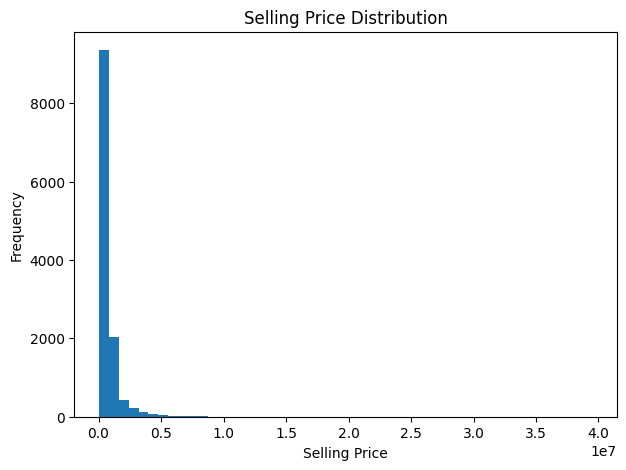

In [41]:
plt.figure(figsize=(7,5))
plt.hist(y_train, bins=50)
plt.xlabel("Selling Price")
plt.ylabel("Frequency")
plt.title("Selling Price Distribution")
plt.show()

In [42]:
y_train_log = np.log1p(y_train)

rf_log = RandomForestRegressor(
    n_estimators=50,
    random_state=42,
    n_jobs=-1
)

rf_log.fit(X_train_encoded, y_train_log)

rf_pred_log = rf_log.predict(X_test_encoded)

rf_pred_price = np.expm1(rf_pred_log)

In [43]:
rf_log = RandomForestRegressor(
    n_estimators=50,
    random_state=42,
    n_jobs=-1
)

rf_log.fit(X_train_encoded, y_train_log)

rf_pred_log = rf_log.predict(X_test_encoded)

rf_pred_price = np.expm1(rf_pred_log)

In [44]:
print("MAE :", mean_absolute_error(y_test, rf_pred_price))
print("RMSE:", np.sqrt(mean_squared_error(y_test, rf_pred_price)))
print("R2  :", r2_score(y_test, rf_pred_price))

MAE : 98207.11257571541
RMSE: 211382.93957867468
R2  : 0.9406431615246168


In [45]:
rf = RandomForestRegressor(
    n_estimators=50,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train_encoded, y_train)

importance = pd.Series(
    rf.feature_importances_,
    index=preprocessor.get_feature_names_out()
)

print(importance.sort_values(ascending=False).head(15))

num__max_power                       0.650257
num__vehicle_age                     0.129472
num__km_driven                       0.050898
num__engine                          0.027834
cat__brand_Ferrari                   0.022333
cat__model_GTC4Lusso                 0.021508
num__mileage                         0.021139
cat__car_name_Ferrari GTC4Lusso      0.014369
cat__car_name_Bentley Continental    0.004466
cat__brand_Rolls-Royce               0.004051
cat__model_Continental               0.003807
cat__brand_Mercedes-Benz             0.003689
cat__model_Rover                     0.002639
cat__brand_Land Rover                0.002600
cat__car_name_Land Rover Rover       0.002152
dtype: float64


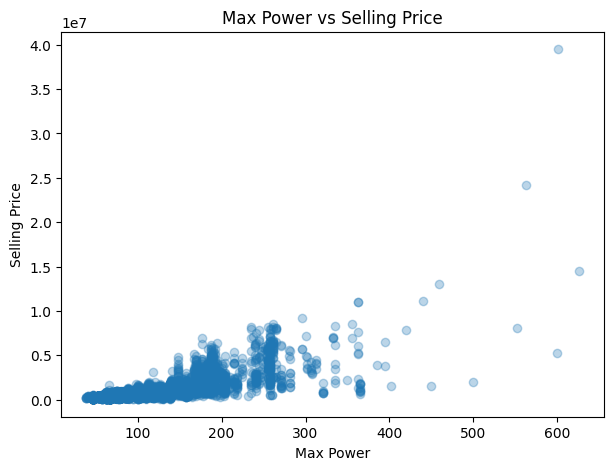

In [46]:
plt.figure(figsize=(7,5))

plt.scatter(
    df['max_power'],
    df['selling_price'],
    alpha=0.3
)

plt.xlabel("Max Power")
plt.ylabel("Selling Price")
plt.title("Max Power vs Selling Price")

plt.show()

In [47]:
importance_df = pd.DataFrame({
    'feature': preprocessor.get_feature_names_out(),
    'importance': rf.feature_importances_
})

importance_df['original_feature'] = (
    importance_df['feature']
    .str.replace(r'^(num__|cat__)', '', regex=True)
    .str.split('_').str[0]
)

print(
    importance_df
    .groupby('original_feature')['importance']
    .sum()
    .sort_values(ascending=False)
)

original_feature
max             0.650257
vehicle         0.129472
km              0.050898
model           0.039794
brand           0.039725
car             0.032560
engine          0.027834
mileage         0.021139
transmission    0.002362
seller          0.002073
seats           0.002070
fuel            0.001815
Name: importance, dtype: float64


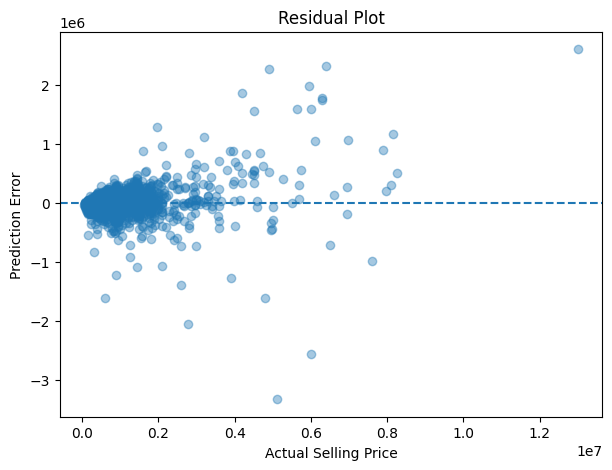

In [48]:
errors = y_test - rf.predict(X_test_encoded)

plt.figure(figsize=(7,5))
plt.scatter(y_test, errors, alpha=0.4)
plt.axhline(0, linestyle='--')

plt.xlabel("Actual Selling Price")
plt.ylabel("Prediction Error")
plt.title("Residual Plot")

plt.show()

In [49]:
print("Final Random Forest Performance")
print("-------------------------------")
print("MAE :", mean_absolute_error(y_test, rf_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, rf_pred)))
print("R2  :", r2_score(y_test, rf_pred))

Final Random Forest Performance
-------------------------------
MAE : 98452.50771281554
RMSE: 212100.5659345804
R2  : 0.9402394549941325


# Feature Engineering

In [50]:
df['power_per_age'] = df['max_power'] / (df['vehicle_age'] + 1)

In [51]:
df['power_per_age'] = df['max_power'] / (df['vehicle_age'] + 1)

X = df.drop('selling_price', axis=1)
y = df['selling_price']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

print(X_train.shape)

(12328, 13)


In [52]:
cat_cols = X.select_dtypes(include='object').columns
num_cols = X.select_dtypes(include='number').columns

preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols),
        ('num', StandardScaler(), num_cols)
    ]
)

X_train_encoded = preprocessor.fit_transform(X_train)
X_test_encoded = preprocessor.transform(X_test)

In [53]:
rf_fe = RandomForestRegressor(
    n_estimators=50,
    max_depth=None,
    min_samples_leaf=1,
    min_samples_split=2,
    random_state=42,
    n_jobs=-1
)

rf_fe.fit(X_train_encoded, y_train)

rf_fe_pred = rf_fe.predict(X_test_encoded)

print("MAE :", mean_absolute_error(y_test, rf_fe_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, rf_fe_pred)))
print("R2  :", r2_score(y_test, rf_fe_pred))

MAE : 100407.89141407842
RMSE: 225874.76061415568
R2  : 0.9322255026257305


In [54]:
df.drop('power_per_age', axis=1, inplace=True)

In [55]:
print(df[['car_name', 'brand', 'model']].head(10))

         car_name    brand     model
0     Maruti Alto   Maruti      Alto
1   Hyundai Grand  Hyundai     Grand
2     Hyundai i20  Hyundai       i20
3     Maruti Alto   Maruti      Alto
4   Ford Ecosport     Ford  Ecosport
5  Maruti Wagon R   Maruti   Wagon R
6     Hyundai i10  Hyundai       i10
7  Maruti Wagon R   Maruti   Wagon R
8   Hyundai Venue  Hyundai     Venue
9    Maruti Swift   Maruti     Swift


In [56]:
X_reduced = df.drop(['selling_price', 'car_name'], axis=1)
y = df['selling_price']

X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(
    X_reduced, y,
    test_size=0.2,
    random_state=42
)

cat_cols_r = X_reduced.select_dtypes(include='object').columns
num_cols_r = X_reduced.select_dtypes(include='number').columns

preprocessor_r = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols_r),
        ('num', StandardScaler(), num_cols_r)
    ]
)

X_train_r_encoded = preprocessor_r.fit_transform(X_train_r)
X_test_r_encoded = preprocessor_r.transform(X_test_r)

In [57]:
rf_reduced = RandomForestRegressor(
    n_estimators=50,
    random_state=42,
    n_jobs=-1
)

rf_reduced.fit(X_train_r_encoded, y_train_r)

pred_r = rf_reduced.predict(X_test_r_encoded)

print("MAE :", mean_absolute_error(y_test_r, pred_r))
print("RMSE:", np.sqrt(mean_squared_error(y_test_r, pred_r)))
print("R2  :", r2_score(y_test_r, pred_r))

MAE : 98667.56843057832
RMSE: 211656.953903245
R2  : 0.940489174018351


In [58]:
X_reduced2 = df.drop(['selling_price', 'car_name', 'brand'], axis=1)
y = df['selling_price']

X_train_r2, X_test_r2, y_train_r2, y_test_r2 = train_test_split(
    X_reduced2, y,
    test_size=0.2,
    random_state=42
)

cat_cols_r2 = X_reduced2.select_dtypes(include='object').columns
num_cols_r2 = X_reduced2.select_dtypes(include='number').columns

preprocessor_r2 = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols_r2),
        ('num', StandardScaler(), num_cols_r2)
    ]
)

X_train_r2_encoded = preprocessor_r2.fit_transform(X_train_r2)
X_test_r2_encoded = preprocessor_r2.transform(X_test_r2)

rf_reduced2 = RandomForestRegressor(
    n_estimators=50,
    random_state=42,
    n_jobs=-1
)

rf_reduced2.fit(X_train_r2_encoded, y_train_r2)

pred_r2 = rf_reduced2.predict(X_test_r2_encoded)

print("MAE :", mean_absolute_error(y_test_r2, pred_r2))
print("RMSE:", np.sqrt(mean_squared_error(y_test_r2, pred_r2)))
print("R2  :", r2_score(y_test_r2, pred_r2))

MAE : 99316.79285539486
RMSE: 216425.6241564162
R2  : 0.9377773859787073


In [59]:
from xgboost import XGBRegressor
xgb_model = XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1
)

xgb_model.fit(X_train_encoded, y_train)

xgb_pred = xgb_model.predict(X_test_encoded)

print("MAE :", mean_absolute_error(y_test, xgb_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, xgb_pred)))
print("R2  :", r2_score(y_test, xgb_pred))

MAE : 96058.9375
RMSE: 204291.10774578515
R2  : 0.9445591568946838


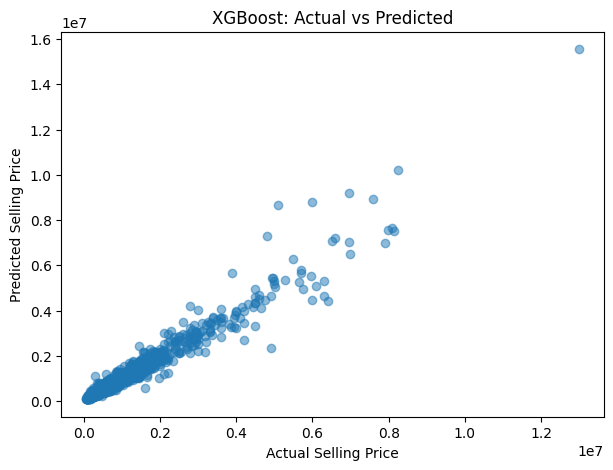

In [60]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7,5))
plt.scatter(y_test, xgb_pred, alpha=0.5)

plt.xlabel("Actual Selling Price")
plt.ylabel("Predicted Selling Price")
plt.title("XGBoost: Actual vs Predicted")
plt.show()

In [61]:
errors = y_test - xgb_pred

print("Mean Error:", errors.mean())
print("MAE:", np.mean(np.abs(errors)))
print("Max Underprediction:", errors.min())
print("Max Overprediction:", errors.max())

Mean Error: -4799.221978389555
MAE: 96058.94641481512
Max Underprediction: -3553021.0
Max Overprediction: 2544177.0


In [62]:
error_df = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": xgb_pred,
    "Error": errors.values
})

error_df["Abs_Error"] = abs(error_df["Error"])

print(error_df.sort_values("Abs_Error", ascending=False).head(10))

        Actual   Predicted      Error  Abs_Error
1079   5100000   8653021.0 -3553021.0  3553021.0
2671   6000000   8777931.0 -2777931.0  2777931.0
500   13000000  15553914.0 -2553914.0  2553914.0
2107   4900000   2355823.0  2544177.0  2544177.0
898    4800000   7306740.5 -2506740.5  2506740.5
2490   6950000   9207847.0 -2257847.0  2257847.0
1157   8250000  10229261.0 -1979261.0  1979261.0
1365   6400000   4429425.5  1970574.5  1970574.5
316    3900000   5666975.0 -1766975.0  1766975.0
2089   6300000   4627995.5  1672004.5  1672004.5


In [63]:
for depth in [3, 5, 7, 9]:
    model = XGBRegressor(
        n_estimators=500,
        learning_rate=0.05,
        max_depth=depth,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        n_jobs=-1
    )

    model.fit(X_train_encoded, y_train)
    pred = model.predict(X_test_encoded)

    print(
        "depth:", depth,
        "MAE:", mean_absolute_error(y_test, pred),
        "RMSE:", np.sqrt(mean_squared_error(y_test, pred)),
        "R2:", r2_score(y_test, pred)
    )

depth: 3 MAE: 112958.6328125 RMSE: 215271.30417220035 R2: 0.9384393692016602
depth: 5 MAE: 98311.4921875 RMSE: 199488.39011832242 R2: 0.9471352696418762
depth: 7 MAE: 93652.8828125 RMSE: 203793.8685633108 R2: 0.9448286890983582
depth: 9 MAE: 92750.078125 RMSE: 211677.70459828782 R2: 0.9404774904251099


In [64]:
for lr in [0.01, 0.03, 0.05, 0.1]:
    model = XGBRegressor(
        n_estimators=500,
        learning_rate=lr,
        max_depth=5,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        n_jobs=-1
    )

    model.fit(X_train_encoded, y_train)
    pred = model.predict(X_test_encoded)

    print(
        "lr:", lr,
        "MAE:", mean_absolute_error(y_test, pred),
        "RMSE:", np.sqrt(mean_squared_error(y_test, pred)),
        "R2:", r2_score(y_test, pred)
    )

lr: 0.01 MAE: 121045.9609375 RMSE: 234567.33412817738 R2: 0.9269086718559265
lr: 0.03 MAE: 105929.5625 RMSE: 211705.48962178567 R2: 0.9404618740081787
lr: 0.05 MAE: 98311.4921875 RMSE: 199488.39011832242 R2: 0.9471352696418762
lr: 0.1 MAE: 93496.546875 RMSE: 194003.53052457576 R2: 0.9500023126602173


In [65]:
for n in [100, 300, 500, 700, 1000]:
    model = XGBRegressor(
        n_estimators=n,
        learning_rate=0.1,
        max_depth=5,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        n_jobs=-1
    )

    model.fit(X_train_encoded, y_train)
    pred = model.predict(X_test_encoded)

    print(
        "n_estimators:", n,
        "MAE:", mean_absolute_error(y_test, pred),
        "RMSE:", np.sqrt(mean_squared_error(y_test, pred)),
        "R2:", r2_score(y_test, pred)
    )

n_estimators: 100 MAE: 112384.390625 RMSE: 221041.0834573519 R2: 0.9350951910018921
n_estimators: 300 MAE: 97940.4296875 RMSE: 198466.14639277905 R2: 0.9476756453514099
n_estimators: 500 MAE: 93496.546875 RMSE: 194003.53052457576 R2: 0.9500023126602173
n_estimators: 700 MAE: 91759.828125 RMSE: 193409.00595370424 R2: 0.9503082633018494
n_estimators: 1000 MAE: 91836.4375 RMSE: 195070.58267201643 R2: 0.9494507908821106


In [66]:
for sub in [0.6, 0.8, 1.0]:
    model = XGBRegressor(
        n_estimators=700,
        learning_rate=0.1,
        max_depth=5,
        subsample=sub,
        colsample_bytree=0.8,
        random_state=42,
        n_jobs=-1
    )

    model.fit(X_train_encoded, y_train)
    pred = model.predict(X_test_encoded)

    print(
        "subsample:", sub,
        "MAE:", mean_absolute_error(y_test, pred),
        "RMSE:", np.sqrt(mean_squared_error(y_test, pred)),
        "R2:", r2_score(y_test, pred)
    )

subsample: 0.6 MAE: 91889.3828125 RMSE: 184856.4803732885 R2: 0.9546058177947998
subsample: 0.8 MAE: 91759.828125 RMSE: 193409.00595370424 R2: 0.9503082633018494
subsample: 1.0 MAE: 93861.7578125 RMSE: 238624.2724954861 R2: 0.9243584871292114


In [67]:
for col in [0.6, 0.8, 1.0]:
    model = XGBRegressor(
        n_estimators=700,
        learning_rate=0.1,
        max_depth=5,
        subsample=0.6,
        colsample_bytree=col,
        random_state=42,
        n_jobs=-1
    )

    model.fit(X_train_encoded, y_train)
    pred = model.predict(X_test_encoded)

    print(
        "colsample:", col,
        "MAE:", mean_absolute_error(y_test, pred),
        "RMSE:", np.sqrt(mean_squared_error(y_test, pred)),
        "R2:", r2_score(y_test, pred)
    )

colsample: 0.6 MAE: 91435.15625 RMSE: 177144.82644435315 R2: 0.9583142399787903
colsample: 0.8 MAE: 91889.3828125 RMSE: 184856.4803732885 R2: 0.9546058177947998
colsample: 1.0 MAE: 92623.59375 RMSE: 191007.8900988124 R2: 0.9515343904495239


In [68]:
for child in [1, 3, 5, 10]:
    model = XGBRegressor(
        n_estimators=700,
        learning_rate=0.1,
        max_depth=5,
        subsample=0.6,
        colsample_bytree=0.6,
        min_child_weight=child,
        random_state=42,
        n_jobs=-1
    )

    model.fit(X_train_encoded, y_train)
    pred = model.predict(X_test_encoded)

    print(
        "min_child_weight:", child,
        "MAE:", mean_absolute_error(y_test, pred),
        "RMSE:", np.sqrt(mean_squared_error(y_test, pred)),
        "R2:", r2_score(y_test, pred)
    )

min_child_weight: 1 MAE: 91435.15625 RMSE: 177144.82644435315 R2: 0.9583142399787903
min_child_weight: 3 MAE: 102758.8828125 RMSE: 379286.8302274678 R2: 0.8088974356651306
min_child_weight: 5 MAE: 104004.4453125 RMSE: 388705.5898543266 R2: 0.7992883920669556
min_child_weight: 10 MAE: 105611.1875 RMSE: 337368.5318342539 R2: 0.8488041162490845


In [69]:
from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(
    model,
    X_train_encoded,
    y_train,
    cv=5,
    scoring='r2',
    n_jobs=-1
)

print("CV R2:", cv_scores)
print("Mean CV R2:", cv_scores.mean())
print("Std CV R2:", cv_scores.std())

CV R2: [0.86962873 0.7697385  0.93488032 0.91610712 0.94293582]
Mean CV R2: 0.8866580963134766
Std CV R2: 0.06374951380840663


In [70]:
best_xgb = XGBRegressor(
    n_estimators=700,
    learning_rate=0.1,
    max_depth=5,
    subsample=0.6,
    colsample_bytree=0.6,
    min_child_weight=1,
    random_state=42,
    n_jobs=-1
)

cv_scores = cross_val_score(
    best_xgb,
    X_train_encoded,
    y_train,
    cv=5,
    scoring='r2',
    n_jobs=-1
)

print("CV R2:", cv_scores)
print("Mean CV R2:", cv_scores.mean())
print("Std CV R2:", cv_scores.std())

CV R2: [0.93194985 0.66735023 0.9417274  0.93980348 0.83065212]
Mean CV R2: 0.8622966170310974
Std CV R2: 0.1059939656563568


In [71]:
print(pd.qcut(y_train, q=5).value_counts().sort_index())

selling_price
(39999.999, 350000.0]     2613
(350000.0, 490000.0]      2347
(490000.0, 650000.0]      2668
(650000.0, 900000.0]      2264
(900000.0, 39500000.0]    2436
Name: count, dtype: int64


In [72]:
print(y_train.describe(percentiles=[.5, .75, .9, .95, .99]))

count    1.232800e+04
mean     7.721206e+05
std      9.006112e+05
min      4.000000e+04
50%      5.600000e+05
75%      8.142500e+05
90%      1.350000e+06
95%      2.050000e+06
99%      4.493650e+06
max      3.950000e+07
Name: selling_price, dtype: float64


In [73]:
final_model = XGBRegressor(
    n_estimators=700,
    learning_rate=0.1,
    max_depth=5,
    subsample=0.6,
    colsample_bytree=0.6,
    min_child_weight=1,
    random_state=42,
    n_jobs=-1
)

final_model.fit(X_train_encoded, y_train)

final_pred = final_model.predict(X_test_encoded)

print("MAE :", mean_absolute_error(y_test, final_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, final_pred)))
print("R2  :", r2_score(y_test, final_pred))

MAE : 91435.15625
RMSE: 177144.82644435315
R2  : 0.9583142399787903


In [90]:
# 1. power_per_age remove
# X = X.drop("power_per_age", axis=1)

# 2. Split again
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# 3. Preprocessor
cat_cols = X.select_dtypes(include='object').columns
num_cols = X.select_dtypes(include='number').columns

preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols),
        ('num', StandardScaler(), num_cols)
    ]
)

# 4. Fit ONLY on training data
X_train_encoded = preprocessor.fit_transform(X_train)
X_test_encoded = preprocessor.transform(X_test)

# 5. Final XGBoost again
final_model = XGBRegressor(
    n_estimators=700,
    learning_rate=0.1,
    max_depth=5,
    subsample=0.6,
    colsample_bytree=0.6,
    min_child_weight=1,
    random_state=42,
    n_jobs=-1
)

final_model.fit(X_train_encoded, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.6, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.1, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=5,
             max_leaves=None, min_child_weight=1, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=700,
             n_jobs=-1, num_parallel_tree=None, ...)

# Real world Business Example

In [92]:

car_df = pd.DataFrame([[
    "Hyundai Creta",
    "Hyundai",
    "Creta",
    3,
    40000,
    "Individual",
    "Diesel",
    "Manual",
    18.5,
    1497,
    113,
    5
]], columns=X.columns)

car_encoded = preprocessor.transform(car_df)

predicted_price = final_model.predict(car_encoded)

print("Predicted Price:", predicted_price[0])

Predicted Price: 1095272.6
